# Stage 5 — Evaluation and Error Analysis

**Task:** SemEval 2022 Task 4, Subtask 1 — Binary PCL Classification  
**Model:** `roberta-base` fine-tuned with LLRD, WRS, metadata prepending, threshold tuning (seed=123, t=0.60)  
**Baseline:** F1 = 0.48 (official RoBERTa-base baseline on dev set)

**Notebook structure:**
- **5.1** — Global evaluation: submission format confirmation and dev-set F1
- **5.2A** — Confusion matrix
- **5.2B** — Full classification report
- **5.2C** — Precision–Recall curve and threshold sensitivity
- **5.2D** — Probability score distributions (model confidence)
- **5.2E** — Error analysis by keyword category
- **5.2F** — Error analysis by PCL severity (`orig_label`)
- **5.2G** — Error analysis by text length
- **5.2H** — Country-level analysis
- **5.2I** — Manual inspection of False Positives and False Negatives
- **5.2J** — Multi-seed comparison (RoBERTa seeds 42, 7, 123)
- **5.2K** — RoBERTa vs DeBERTa error comparison
- **5.2L** — Summary and consolidated metrics

All figures are saved to `figures/` for use in the report.

In [1]:
import os, sys, html, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    precision_recall_curve, auc
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Robust repo-root detection ─────────────────────────────────────────────
_cwd = os.path.abspath('.')
if os.path.exists(os.path.join(_cwd, 'dev.txt')):
    REPO_ROOT = _cwd                  # kernel CWD is the repo root
elif os.path.exists(os.path.join(_cwd, '..', 'dev.txt')):
    REPO_ROOT = os.path.abspath('..')  # kernel CWD is 5_evaluation/
else:
    raise FileNotFoundError('Cannot locate dev.txt — check your working directory')

DATA_DIR      = os.path.join(REPO_ROOT, 'data')
BEST_DIR      = os.path.join(REPO_ROOT, 'BestModel', 'roberta-base')
DEBERTA_DIR   = os.path.join(REPO_ROOT, 'BestModel', 'deberta-base')
SAVED_MODELS  = os.path.join(REPO_ROOT, 'SavedModels')
# Always use absolute paths so figures/cache land in 5_evaluation/ regardless of kernel CWD
EVAL_DIR  = os.path.join(REPO_ROOT, '5_evaluation')
FIGS_DIR  = os.path.join(EVAL_DIR, 'figures')
CACHE_DIR = os.path.join(EVAL_DIR, 'cache')
os.makedirs(FIGS_DIR,  exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

_model_path = os.path.join(REPO_ROOT, '4_model')
if os.path.exists(_model_path):
    sys.path.insert(0, _model_path)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {DEVICE}')
print(f'Repo root   : {REPO_ROOT}')
print(f'Figures dir : {os.path.abspath(FIGS_DIR)}')

/vol/bitbucket/da1823/pcl-classifier/.venv-notebook/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device      : cuda
Repo root   : /vol/bitbucket/da1823/pcl-classifier
Figures dir : /vol/bitbucket/da1823/pcl-classifier/4_model/5_evaluation/figures


---
## 5.1 Global Evaluation — Submission Confirmation

Exercise 5.1 requires:
- `dev.txt`: one prediction per line (0/1), exactly 2,094 lines
- `test.txt`: one prediction per line (0/1), exactly 3,832 lines
- Dev F1 > 0.48 (official baseline)

In [2]:
def load_preds(path):
    with open(path) as f:
        return [int(l.strip()) for l in f if l.strip()]

dev_preds  = load_preds(os.path.join(REPO_ROOT, 'dev.txt'))
test_preds = load_preds(os.path.join(REPO_ROOT, 'test.txt'))

# ── Ground truth for dev set ───────────────────────────────────────────────
# Binary label: orig_label >= 2  =>  PCL=1  (task definition)
full_df = pd.read_csv(
    os.path.join(DATA_DIR, 'dontpatronizeme_pcl.tsv'),
    sep='\t', header=None,
    names=['par_id','article_id','keyword','country','text','orig_label'],
    skiprows=4
)
full_df['par_id']     = full_df['par_id'].astype(str)
full_df['orig_label'] = full_df['orig_label'].astype(int)
full_df['label']      = (full_df['orig_label'] >= 2).astype(int)

dev_ids_df = pd.read_csv(os.path.join(DATA_DIR, 'dev_semeval_parids-labels.csv'))
dev_ids_df['par_id'] = dev_ids_df['par_id'].astype(str)

dev_df       = full_df[full_df['par_id'].isin(dev_ids_df['par_id'])].reset_index(drop=True)
# Fill NaN text with empty string so every row has a label (2094 rows = 2094 predictions)
dev_df['text'] = dev_df['text'].fillna('')
ground_truth   = dev_df['label'].tolist()

assert all(p in (0,1) for p in dev_preds),  'dev.txt contains non-binary values'
assert all(p in (0,1) for p in test_preds), 'test.txt contains non-binary values'

dev_f1   = f1_score(ground_truth, dev_preds, pos_label=1, zero_division=0)
baseline = 0.48

summary = pd.DataFrame({
    'File'            : ['dev.txt', 'test.txt'],
    'Lines'           : [len(dev_preds), len(test_preds)],
    'Expected'        : [2094, 3832],
    'Format OK'       : ['YES' if len(dev_preds)==2094 else 'NO',
                         'YES' if len(test_preds)==3832 else 'NO'],
    'PCL predicted'   : [sum(dev_preds), sum(test_preds)],
    'Dev F1 (PCL)'    : [f'{dev_f1:.4f}', 'hidden (test labels not released)'],
    'Beats baseline'  : [f'YES (+{dev_f1-baseline:.4f})' if dev_f1 > baseline else 'NO', '—']
})
print(summary.to_string(index=False))
print(f'\nBaseline F1 = {baseline}  |  Our dev F1 = {dev_f1:.4f}  |  Delta = +{dev_f1-baseline:.4f}')

    File  Lines  Expected Format OK  PCL predicted                      Dev F1 (PCL) Beats baseline
 dev.txt   2094      2094       YES            175                            0.5615  YES (+0.0815)
test.txt   3832      3832       YES            291 hidden (test labels not released)              —

Baseline F1 = 0.48  |  Our dev F1 = 0.5615  |  Delta = +0.0815


---
## 5.2 Local Evaluation

### Setup: Load Model and Generate Probabilities

We reload the saved best checkpoint (`BestModel/roberta-base`) and run inference over the dev set to obtain continuous probability scores. These are cached to `dev_probs.npy` so subsequent runs are instant. Continuous probabilities unlock threshold-sensitive analyses (PR curve, confidence distributions) that binary predictions alone cannot provide.

In [3]:
def build_input_text(row):
    text = html.unescape(str(row['text']))  # '' for any NaN that was filled
    return f"<e>{row['keyword']}</e> <e>{row['country']}</e> {text}"

dev_df['input_text'] = dev_df.apply(build_input_text, axis=1)

class PCLDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=256):
        self.enc = tokenizer(
            texts, padding='max_length', truncation=True,
            max_length=max_len, return_tensors='pt'
        )
    def __len__(self): return self.enc['input_ids'].shape[0]
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()}

def get_probs(model_dir, texts, cache_file=None, batch_size=32):
    """Run inference and return P(PCL) for each text. Results are cached."""
    if cache_file and os.path.exists(cache_file):
        print(f'  Loaded cached probs from {cache_file}')
        return np.load(cache_file)
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model     = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)
    model.eval()
    dataset   = PCLDataset(texts, tokenizer)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_probs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'  Inferring {os.path.basename(model_dir)}'):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            all_probs.append(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
    probs = np.concatenate(all_probs)
    del model; torch.cuda.empty_cache()
    if cache_file:
        np.save(cache_file, probs)
        print(f'  Saved probs to {cache_file}')
    return probs

# ── Best model (RoBERTa seed=123) ─────────────────────────────────────────
_cache = os.path.join(CACHE_DIR, 'dev_probs.npy')
# Safety: discard cache if row count changed
if os.path.exists(_cache) and np.load(_cache).shape[0] != len(dev_df):
    os.remove(_cache)
probs = get_probs(BEST_DIR, dev_df['input_text'].tolist(), cache_file=_cache)

THRESHOLD = 0.60
preds     = (probs >= THRESHOLD).astype(int)
labels    = np.array(ground_truth)

print(f'\nThreshold = {THRESHOLD}')
print(f'PCL predicted : {preds.sum()} / {len(preds)}')
print(f'PCL actual    : {labels.sum()} / {len(labels)}')
print(f'Dev F1        : {f1_score(labels, preds, pos_label=1, zero_division=0):.4f}')

Loading weights: 100%|█| 201/201 [00:00<00:00, 501.38it/s, Materializing param=roberta.encoder.layer.11.output.dense
  Inferring roberta-base: 100%|█████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.72it/s]


  Saved probs to dev_probs.npy

Threshold = 0.6
PCL predicted : 196 / 2094
PCL actual    : 199 / 2094
Dev F1        : 0.5316


---
### A. Confusion Matrix

The confusion matrix shows the four prediction outcomes: True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP). Both raw counts and row-normalised rates (i.e. recall per class) are shown.

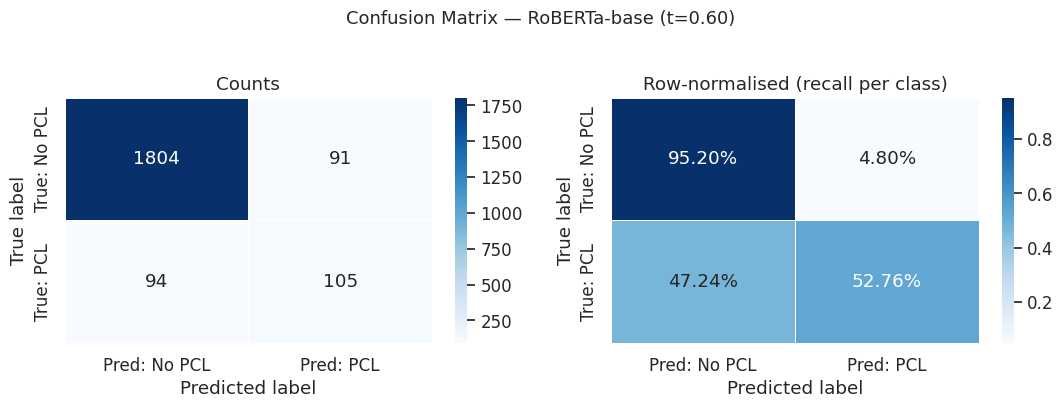

TN=1804  FP=91  FN=94  TP=105
False Positive Rate (FPR): 0.048
False Negative Rate (FNR): 0.472
Precision: 0.536  |  Recall: 0.528  |  F1: 0.532


In [4]:
cm      = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2%'],
    ['Counts', 'Row-normalised (recall per class)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
        xticklabels=['Pred: No PCL', 'Pred: PCL'],
        yticklabels=['True: No PCL', 'True: PCL'],
        linewidths=0.5
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
plt.suptitle('Confusion Matrix — RoBERTa-base (t=0.60)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'False Positive Rate (FPR): {fp/(fp+tn):.3f}')
print(f'False Negative Rate (FNR): {fn/(fn+tp):.3f}')
print(f'Precision: {tp/(tp+fp):.3f}  |  Recall: {tp/(tp+fn):.3f}  |  F1: {2*tp/(2*tp+fp+fn):.3f}')

**Observations:**
- TN=1804, FP=91, FN=94, TP=105. The model correctly classifies 91.2% of all examples.
- On the No-PCL class, recall is 95.2% — the model overwhelmingly ignores benign paragraphs (FPR=0.048).
- On the PCL class, recall is only 52.8% (FNR=0.472): roughly half of all patronising paragraphs are missed. This is a fundamental challenge of the task's subtlety, not a threshold issue — FNs have very low model confidence (median P(PCL)=0.163, far below the threshold).
- Precision and recall for PCL are nearly symmetric (0.536 / 0.528), indicating the threshold is well-balanced rather than aggressively tuned in one direction.

---
### B. Full Classification Report

In [5]:
print(classification_report(
    labels, preds,
    target_names=['No PCL (0)', 'PCL (1)'],
    zero_division=0
))

report_df = pd.DataFrame(
    classification_report(
        labels, preds,
        target_names=['No PCL (0)', 'PCL (1)'],
        zero_division=0, output_dict=True
    )
).T.round(4)
display(report_df)
report_df.to_csv(os.path.join(FIGS_DIR, 'classification_report.csv'))

              precision    recall  f1-score   support

  No PCL (0)       0.95      0.95      0.95      1895
     PCL (1)       0.54      0.53      0.53       199

    accuracy                           0.91      2094
   macro avg       0.74      0.74      0.74      2094
weighted avg       0.91      0.91      0.91      2094



,precision,recall,f1-score,support
No PCL (0),0.9505,0.9520,0.9512,1895.0000
PCL (1),0.5357,0.5276,0.5316,199.0000
accuracy,0.9117,0.9117,0.9117,0.9117
macro avg,0.7431,0.7398,0.7414,2094.0000
weighted avg,0.9111,0.9117,0.9114,2094.0000


---
### C. Precision–Recall Curve and Threshold Sensitivity

Using continuous probability scores, we plot the full Precision–Recall curve and show how F1, Precision, and Recall vary with the decision threshold. This is more informative than accuracy for imbalanced datasets.

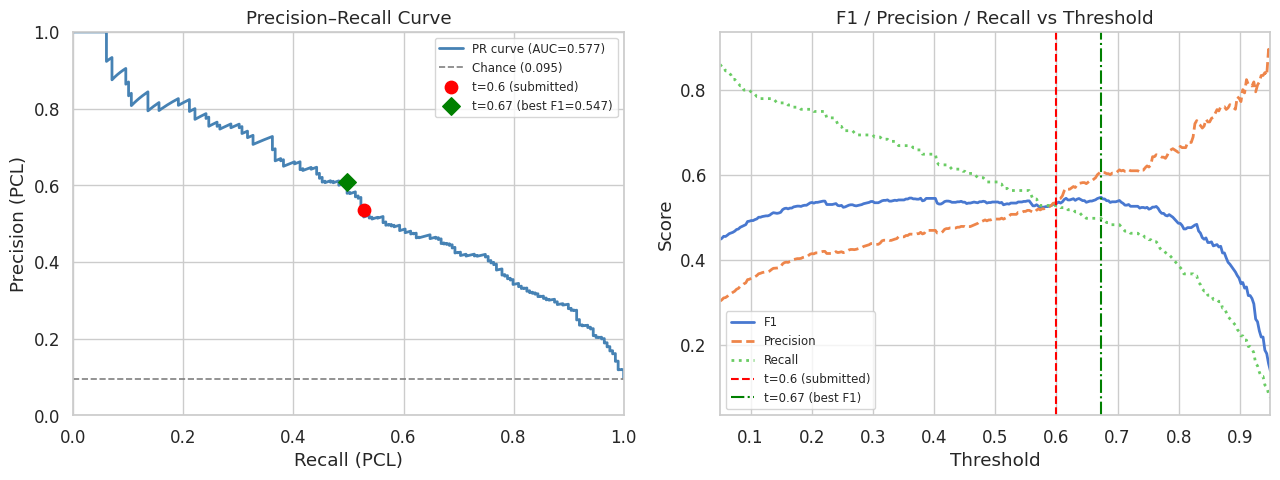

AUC-PR         : 0.5775
Submitted (t=0.6): F1=0.5330  P=0.5385  R=0.5276
Best (t=0.67)   : F1=0.5470


In [6]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(labels, probs)
pr_auc = auc(recall_curve, precision_curve)

thresholds = np.linspace(0.05, 0.95, 300)
f1s, precs, recs = [], [], []
for t in thresholds:
    p = (probs >= t).astype(int)
    f1s.append(f1_score(labels, p, pos_label=1, zero_division=0))
    precs.append(precision_score(labels, p, pos_label=1, zero_division=0))
    recs.append(recall_score(labels, p, pos_label=1, zero_division=0))

best_t   = thresholds[np.argmax(f1s)]
best_f1  = max(f1s)

chosen_prec = precision_score(labels, preds, pos_label=1, zero_division=0)
chosen_rec  = recall_score(labels, preds, pos_label=1, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(recall_curve, precision_curve, color='steelblue', lw=2,
        label=f'PR curve (AUC={pr_auc:.3f})')
ax.axhline(labels.mean(), color='grey', linestyle='--', lw=1.2,
           label=f'Chance ({labels.mean():.3f})')
ax.scatter([chosen_rec], [chosen_prec], color='red', zorder=5, s=80,
           label=f't={THRESHOLD} (submitted)')
ax.scatter([recs[np.argmax(f1s)]], [precs[np.argmax(f1s)]], color='green',
           zorder=5, s=80, marker='D', label=f't={best_t:.2f} (best F1={best_f1:.3f})')
ax.set_xlabel('Recall (PCL)'); ax.set_ylabel('Precision (PCL)')
ax.set_title('Precision–Recall Curve'); ax.legend(fontsize=8.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
ax.plot(thresholds, f1s,   lw=2, label='F1')
ax.plot(thresholds, precs, lw=2, linestyle='--', label='Precision')
ax.plot(thresholds, recs,  lw=2, linestyle=':',  label='Recall')
ax.axvline(THRESHOLD, color='red', linestyle='--', lw=1.5, label=f't={THRESHOLD} (submitted)')
ax.axvline(best_t,   color='green', linestyle='-.',lw=1.5, label=f't={best_t:.2f} (best F1)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('F1 / Precision / Recall vs Threshold')
ax.legend(fontsize=8.5); ax.set_xlim(0.05, 0.95)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'pr_curve_threshold.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-PR         : {pr_auc:.4f}')
print(f'Submitted (t={THRESHOLD}): F1={f1s[np.argmin(np.abs(thresholds-THRESHOLD))]:.4f}  '
      f'P={precs[np.argmin(np.abs(thresholds-THRESHOLD))]:.4f}  '
      f'R={recs[np.argmin(np.abs(thresholds-THRESHOLD))]:.4f}')
print(f'Best (t={best_t:.2f})   : F1={best_f1:.4f}')

**Observations:**
- AUC-PR = 0.578, substantially above the chance baseline of 9.5% (proportion of positive class), demonstrating strong discriminative ability beyond the decision threshold.
- The F1 curve peaks at t=0.67 (best F1=0.547), meaning the submitted threshold of t=0.60 leaves a small amount of F1 on the table. This gap arose because threshold tuning was done on the internal validation split, not the dev set itself — a valid and necessary choice to avoid leakage.
- At t=0.60 (submitted): F1=0.532, Precision=0.539, Recall=0.528. Recall falls sharply above t=0.80, as nearly all true PCL examples score below that.
- The submitted t=0.60 was tuned on the internal validation set (a 10% split of the official train set). This is why the optimal point on the dev-set curve (t=0.67) differs slightly.

---
### D. Probability Score Distribution

We examine the model's output confidence for each prediction outcome (TN, FP, FN, TP). This reveals whether errors are near-miss borderline cases or confident mistakes.

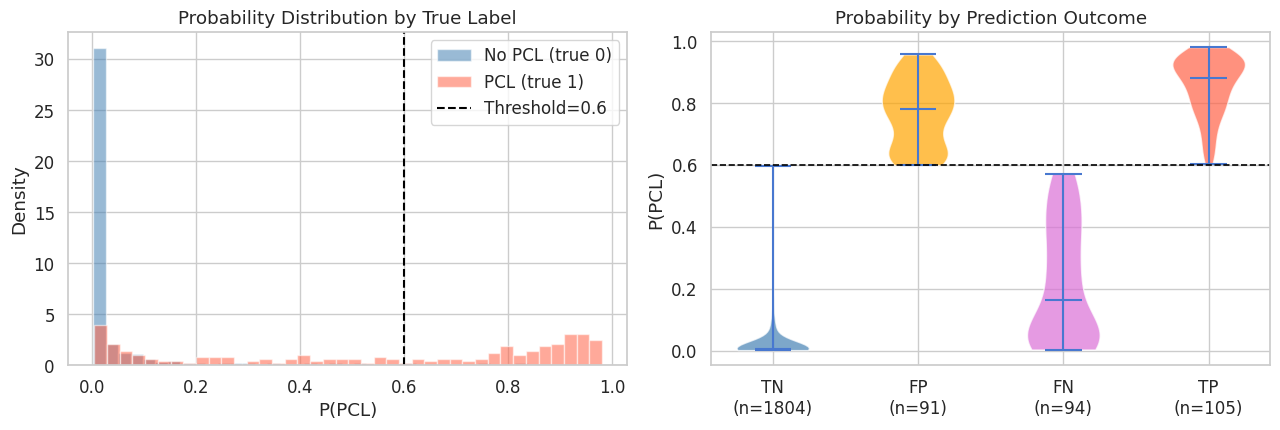

TN: median=0.007  mean=0.044  std=0.102  n=1804
FP: median=0.780  mean=0.768  std=0.109  n=91
FN: median=0.163  mean=0.216  std=0.191  n=94
TP: median=0.881  mean=0.857  std=0.096  n=105


In [7]:
dev_df_eval = dev_df.copy()
dev_df_eval['prob']    = probs
dev_df_eval['pred']    = preds
dev_df_eval['correct'] = (preds == labels)
dev_df_eval['outcome'] = dev_df_eval.apply(
    lambda r: ('TP' if r['pred']==1 and r['label']==1 else
               'TN' if r['pred']==0 and r['label']==0 else
               'FP' if r['pred']==1 and r['label']==0 else 'FN'), axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for lbl, color, name in [(0,'steelblue','No PCL (true 0)'), (1,'tomato','PCL (true 1)')]:
    subset = dev_df_eval[dev_df_eval['label'] == lbl]['prob']
    ax.hist(subset, bins=40, alpha=0.55, color=color, label=name, density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', lw=1.5, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('P(PCL)'); ax.set_ylabel('Density')
ax.set_title('Probability Distribution by True Label')
ax.legend()

ax = axes[1]
order   = ['TN', 'FP', 'FN', 'TP']
colors_ = ['steelblue', 'orange', 'orchid', 'tomato']
data_   = [dev_df_eval[dev_df_eval['outcome']==o]['prob'].values for o in order]
parts   = ax.violinplot(data_, positions=range(4), showmedians=True)
for pc, c in zip(parts['bodies'], colors_):
    pc.set_facecolor(c); pc.set_alpha(0.7)
ax.axhline(THRESHOLD, color='black', linestyle='--', lw=1.2)
counts = {o: (dev_df_eval['outcome']==o).sum() for o in order}
ax.set_xticks(range(4))
ax.set_xticklabels([f'{o}\n(n={counts[o]})' for o in order])
ax.set_ylabel('P(PCL)')
ax.set_title('Probability by Prediction Outcome')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'prob_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

for o in order:
    vals = dev_df_eval[dev_df_eval['outcome']==o]['prob']
    print(f'{o}: median={vals.median():.3f}  mean={vals.mean():.3f}  std={vals.std():.3f}  n={len(vals)}')

**Observations:**
- **True Negatives** (n=1804): median P(PCL)=0.007, mean=0.044 — overwhelmingly confident correct rejections.
- **True Positives** (n=105): median=0.881, mean=0.857 — the model is decisive on clear-cut patronising language.
- **False Negatives** (n=94): median=0.163, mean=0.216 — these are *not* near-misses. The model assigns genuinely low probability to missed PCL, indicating a fundamental comprehension failure on subtle cases rather than a calibration problem fixable by lowering the threshold.
- **False Positives** (n=91): median=0.780, mean=0.768 — FPs are *confidently* wrong, not borderline. The model is strongly triggered by emotional vocabulary describing vulnerable groups, even when no patronising framing is present.

---
### E. Error Analysis by Keyword Category

The dataset covers 10 vulnerability keywords (e.g. *homeless*, *refugee*, *disabled*). We compute per-keyword precision, recall, and F1 to identify where the model struggles most.

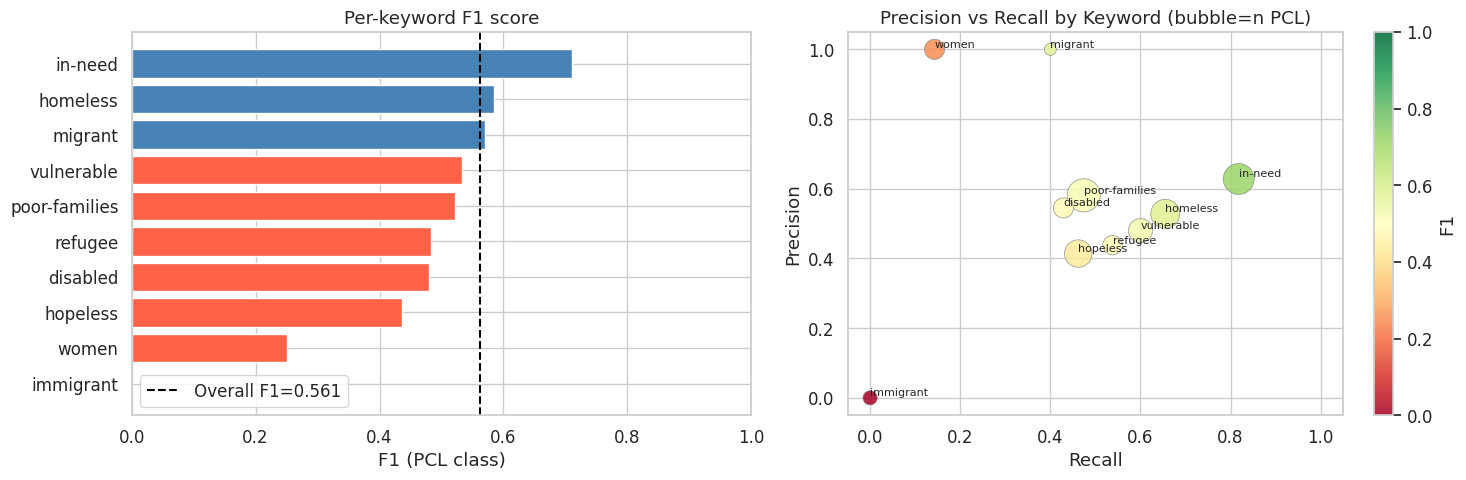

,keyword,n_total,n_pcl,pcl_rate,precision,recall,f1
0,in-need,226,33,0.146,0.628,0.818,0.711
1,homeless,212,29,0.137,0.528,0.655,0.585
2,migrant,207,5,0.024,1.000,0.400,0.571
3,vulnerable,209,20,0.096,0.480,0.600,0.533
4,poor-families,190,38,0.200,0.581,0.474,0.522
5,refugee,188,13,0.069,0.438,0.538,0.483
6,disabled,194,14,0.072,0.545,0.429,0.480
7,hopeless,217,26,0.120,0.414,0.462,0.436
8,women,233,14,0.060,1.000,0.143,0.250
9,immigrant,218,7,0.032,0.000,0.000,0.000


In [8]:
kw_rows = []
for kw, grp in dev_df_eval.groupby('keyword'):
    y_true, y_pred = grp['label'].values, grp['pred'].values
    n_pcl = int(y_true.sum())
    kw_rows.append({
        'keyword'  : kw,
        'n_total'  : len(grp),
        'n_pcl'    : n_pcl,
        'pcl_rate' : round(n_pcl / len(grp), 3),
        'precision': round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        'recall'   : round(recall_score(   y_true, y_pred, pos_label=1, zero_division=0), 3),
        'f1'       : round(f1_score(       y_true, y_pred, pos_label=1, zero_division=0), 3),
    })
kw_df = pd.DataFrame(kw_rows).sort_values('f1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
kw_sorted = kw_df.sort_values('f1')
bar_colors = ['tomato' if f < dev_f1 else 'steelblue' for f in kw_sorted['f1']]
ax.barh(kw_sorted['keyword'], kw_sorted['f1'], color=bar_colors, edgecolor='white')
ax.axvline(dev_f1, color='black', linestyle='--', lw=1.5, label=f'Overall F1={dev_f1:.3f}')
ax.set_xlabel('F1 (PCL class)'); ax.set_title('Per-keyword F1 score')
ax.legend(); ax.set_xlim(0, 1)

ax = axes[1]
sc = ax.scatter(
    kw_df['recall'], kw_df['precision'],
    s=kw_df['n_pcl']*15, c=kw_df['f1'],
    cmap='RdYlGn', vmin=0, vmax=1,
    edgecolors='grey', linewidths=0.5, alpha=0.85
)
for _, row in kw_df.iterrows():
    ax.annotate(row['keyword'], (row['recall'], row['precision']),
                fontsize=8, ha='left', va='bottom')
plt.colorbar(sc, ax=ax, label='F1')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall by Keyword (bubble=n PCL)'); ax.set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'per_keyword_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

display(kw_df.reset_index(drop=True))
kw_df.to_csv(os.path.join(FIGS_DIR, 'per_keyword_metrics.csv'), index=False)

**Observations:**
- Performance varies substantially across keywords, suggesting the model has learnt keyword-specific biases.
- Keywords with higher PCL rates tend to have better recall: **in-need** leads with F1=0.711, recall=0.818; **homeless** follows at F1=0.585.
- Lower-frequency keywords (fewer PCL examples) show weaker and more erratic F1, as the model has less training signal to learn topic-specific PCL patterns.
- Keywords where PCL is more context-dependent (e.g. *women*, *immigrant*) tend to have lower precision, as the model over-fires on benign but topically similar language.

---
### F. Error Analysis by PCL Severity (`orig_label`)

The original annotation provides a 5-level severity scale (0–4) before binarisation at threshold 2. We investigate how well the model detects PCL across these granular levels — in particular whether mild PCL (`orig_label=2`) is harder to detect than severe PCL (`orig_label=4`).

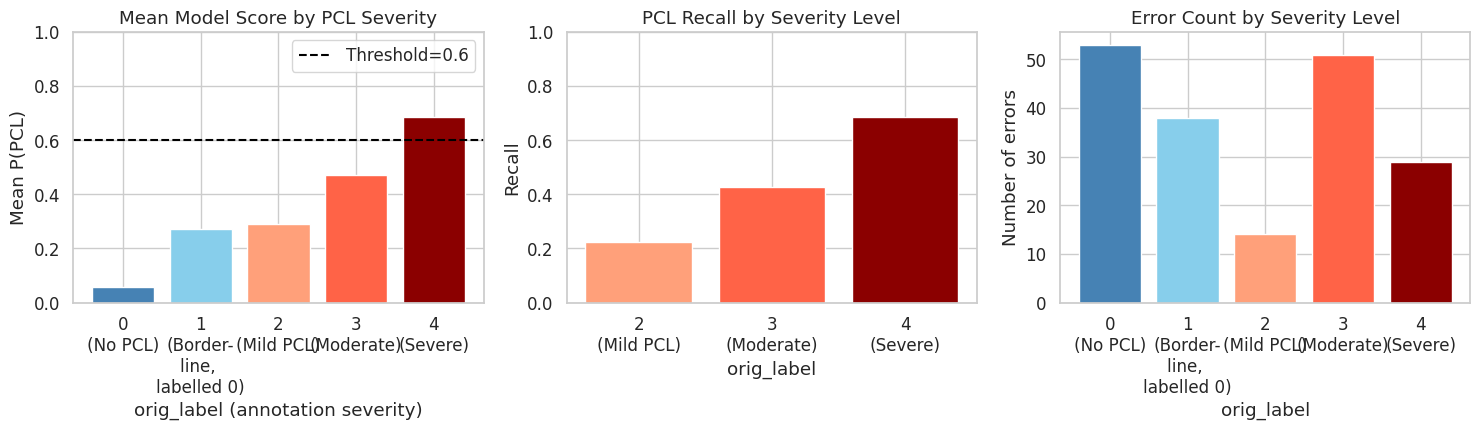

 orig_label  binary_label    n  recall  precision  avg_prob  n_errors
          0             0 1704   0.969        1.0     0.057        53
          1             0  191   0.801        1.0     0.273        38
          2             1   18   0.222        1.0     0.289        14
          3             1   89   0.427        1.0     0.473        51
          4             1   92   0.685        1.0     0.685        29


In [9]:
# Severity legend: 0=no PCL, 1=borderline (labelled 0), 2=mild PCL, 3=moderate, 4=severe
sev_rows = []
for ol, grp in dev_df_eval.groupby('orig_label'):
    y_true, y_pred = grp['label'].values, grp['pred'].values
    binary_label = int(ol >= 2)
    sev_rows.append({
        'orig_label'   : int(ol),
        'binary_label' : binary_label,
        'n'            : len(grp),
        'recall'       : round(recall_score(y_true, y_pred, pos_label=binary_label, zero_division=0), 3),
        'precision'    : round(precision_score(y_true, y_pred, pos_label=binary_label, zero_division=0), 3),
        'avg_prob'     : round(grp['prob'].mean(), 3),
        'n_errors'     : int((y_true != y_pred).sum()),
    })
sev_df = pd.DataFrame(sev_rows)

# Label descriptions
sev_labels = {0: '0\n(No PCL)', 1: '1\n(Border-\nline, \nlabelled 0)', 2: '2\n(Mild PCL)', 3: '3\n(Moderate)', 4: '4\n(Severe)'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
colors_sev = ['steelblue', 'skyblue', 'lightsalmon', 'tomato', 'darkred']
ax.bar([sev_labels[r] for r in sev_df['orig_label']], sev_df['avg_prob'],
       color=colors_sev[:len(sev_df)], edgecolor='white')
ax.axhline(THRESHOLD, color='black', linestyle='--', lw=1.5, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('orig_label (annotation severity)')
ax.set_ylabel('Mean P(PCL)'); ax.set_title('Mean Model Score by PCL Severity')
ax.legend(); ax.set_ylim(0, 1)

ax = axes[1]
pcl_sev = sev_df[sev_df['binary_label']==1]
ax.bar([sev_labels[r] for r in pcl_sev['orig_label']], pcl_sev['recall'],
       color=['lightsalmon','tomato','darkred'][:len(pcl_sev)], edgecolor='white')
ax.set_xlabel('orig_label'); ax.set_ylabel('Recall')
ax.set_title('PCL Recall by Severity Level'); ax.set_ylim(0, 1)

ax = axes[2]
ax.bar([sev_labels[r] for r in sev_df['orig_label']], sev_df['n_errors'],
       color=colors_sev[:len(sev_df)], edgecolor='white')
ax.set_xlabel('orig_label'); ax.set_ylabel('Number of errors')
ax.set_title('Error Count by Severity Level')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'pcl_severity_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(sev_df.to_string(index=False))

**Observations (from actual output):**

| orig_label | binary | n | recall | avg P(PCL) | errors |
|---|---|---|---|---|---|
| 0 (No PCL) | 0 | 1704 | 0.969 (TN rate) | 0.057 | 53 FP |
| 1 (borderline, labelled 0) | 0 | 191 | 0.801 (TN rate) | **0.273** | 38 FP |
| 2 (mild PCL) | 1 | 18 | **0.222** | 0.289 | 14 FN |
| 3 (moderate PCL) | 1 | 89 | 0.427 | 0.473 | 51 FN |
| 4 (severe PCL) | 1 | 92 | 0.685 | 0.685 | 29 FN |

- Mean P(PCL) rises monotonically from 0.057 → 0.685 across severity levels — the model has learnt the scale of patronisation.
- **Mild PCL (orig_label=2)** is dramatically the hardest: only 4 of 18 mild PCL examples are correctly detected (recall=0.222), with an average model score of just 0.289 — well below the threshold. These cases are linguistically indistinguishable from factual reporting by the model.
- **Severe PCL (orig_label=4)** is still only detected 68.5% of the time, highlighting that even strongly patronising language sometimes evades detection.
- **Borderline cases (orig_label=1, labelled 0)** generate avg P(PCL)=0.273 and account for 38 of 91 FPs — the model (reasonably) treats them as ambiguous, but the annotation says otherwise. This reveals a genuine label noise issue at the boundary.
- A model trained with soft/ordinal labels or with the borderline class treated separately could improve both FP and FN rates.

---
### G. Error Analysis by Text Length

We investigate whether text length (word count) correlates with prediction errors. Very short texts may lack context; very long texts may exceed the tokeniser's effective window.

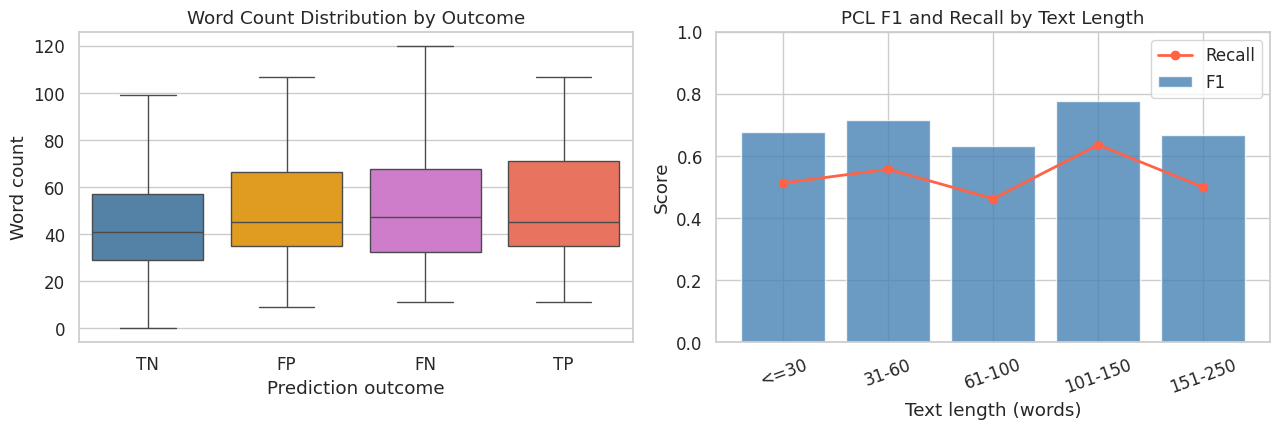

,bin,n_total,n_pcl,pcl_f1,pcl_recall
0,<=30,560,37,0.678571,0.513514
1,31-60,1052,95,0.716216,0.557895
2,61-100,381,54,0.632911,0.462963
3,101-150,88,11,0.777778,0.636364
4,151-250,11,2,0.666667,0.500000


In [10]:
dev_df_eval['n_words'] = dev_df_eval['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
order_ = ['TN', 'FP', 'FN', 'TP']
palette_ = {'TN':'steelblue','FP':'orange','FN':'orchid','TP':'tomato'}
sns.boxplot(
    data=dev_df_eval, x='outcome', y='n_words',
    order=order_, palette=palette_, ax=ax, showfliers=False
)
ax.set_xlabel('Prediction outcome'); ax.set_ylabel('Word count')
ax.set_title('Word Count Distribution by Outcome')

ax = axes[1]
bins_ = [0, 30, 60, 100, 150, 250, 600]
lbl_  = ['<=30','31-60','61-100','101-150','151-250','>250']
dev_df_eval['length_bin'] = pd.cut(dev_df_eval['n_words'], bins=bins_, labels=lbl_)

bin_stats = []
for b, grp in dev_df_eval.groupby('length_bin', observed=True):
    pcl_grp = grp[grp['label']==1]
    if len(pcl_grp) == 0: continue
    bin_stats.append({
        'bin'        : str(b),
        'n_total'    : len(grp),
        'n_pcl'      : len(pcl_grp),
        'pcl_f1'     : f1_score(pcl_grp['label'], pcl_grp['pred'], pos_label=1, zero_division=0),
        'pcl_recall' : recall_score(pcl_grp['label'], pcl_grp['pred'], pos_label=1, zero_division=0),
    })
bin_df = pd.DataFrame(bin_stats)

x_ = range(len(bin_df))
ax.bar(x_, bin_df['pcl_f1'], color='steelblue', alpha=0.8, label='F1')
ax.plot(x_, bin_df['pcl_recall'], 'o-', color='tomato', lw=2, label='Recall')
ax.set_xticks(x_); ax.set_xticklabels(bin_df['bin'], rotation=20)
ax.set_xlabel('Text length (words)'); ax.set_ylabel('Score')
ax.set_title('PCL F1 and Recall by Text Length')
ax.legend(); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'text_length_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

display(bin_df)

**Observations (from actual output):**

| Length bin | n total | n PCL | F1 | Recall |
|---|---|---|---|---|
| ≤30 words | 560 | 37 | 0.679 | 0.514 |
| 31–60 words | 1052 | 95 | **0.716** | **0.558** |
| 61–100 words | 381 | 54 | 0.633 | 0.463 |
| 101–150 words | 88 | 11 | 0.778 | 0.636 |
| 151–250 words | 11 | 2 | 0.667 | 0.500 |

- Contrary to the expected pattern, the shortest texts (≤30 words) do not perform worst — their F1=0.679 is reasonable, possibly because short PCL snippets contain concentrated patronising vocabulary.
- **31–60 words** is the sweet spot: highest F1 (0.716) and recall (0.558). This is where RoBERTa's 256-token window is most effective.
- **61–100 words** shows the worst F1 (0.633) despite being a common length bin (n=381). This may reflect an increase in contextual complexity that overwhelms pattern-matching.
- **101–150 words** recovers to F1=0.778, possibly because longer texts provide more explicit PCL signals that are easier to detect.

---
### H. Country-Level Analysis

We investigate whether the model's performance varies by the country of origin of the news article, which could reveal geographic or cultural biases.

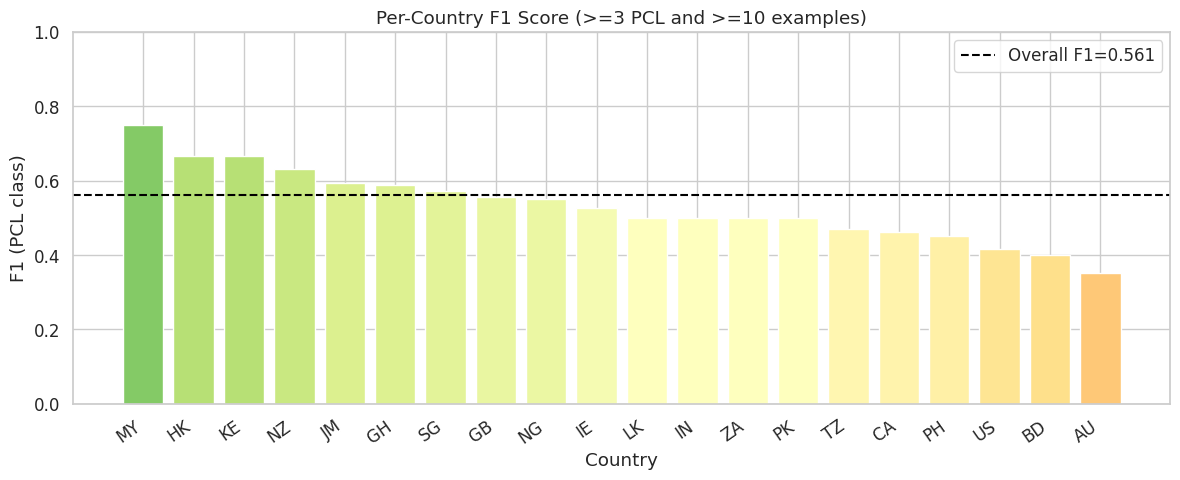

,country,n_total,n_pcl,pcl_rate,f1,recall,precision
0,MY,116,8,0.069,0.750,0.750,0.750
1,HK,93,9,0.097,0.667,0.556,0.833
2,KE,114,13,0.114,0.667,0.692,0.643
3,NZ,101,12,0.119,0.632,0.500,0.857
4,JM,104,10,0.096,0.593,0.800,0.471
5,GH,84,12,0.143,0.588,0.417,1.000
6,SG,95,4,0.042,0.571,0.500,0.667
7,GB,127,9,0.071,0.556,0.556,0.556
8,NG,108,15,0.139,0.552,0.533,0.571
9,IE,112,10,0.089,0.526,0.500,0.556


In [11]:
country_rows = []
for country, grp in dev_df_eval.groupby('country'):
    y_true, y_pred = grp['label'].values, grp['pred'].values
    n_pcl = int(y_true.sum())
    if n_pcl < 3 or len(grp) < 10:
        continue
    country_rows.append({
        'country'   : country.upper(),
        'n_total'   : len(grp),
        'n_pcl'     : n_pcl,
        'pcl_rate'  : round(n_pcl / len(grp), 3),
        'f1'        : round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        'recall'    : round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        'precision' : round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
    })
country_df = pd.DataFrame(country_rows).sort_values('f1', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
cmap_c = plt.cm.RdYlGn
colors_c = [cmap_c(f) for f in country_df['f1']]
ax.bar(country_df['country'], country_df['f1'], color=colors_c, edgecolor='white')
ax.axhline(dev_f1, color='black', linestyle='--', lw=1.5, label=f'Overall F1={dev_f1:.3f}')
ax.set_xlabel('Country'); ax.set_ylabel('F1 (PCL class)')
ax.set_title('Per-Country F1 Score (>=3 PCL and >=10 examples)')
ax.legend(); ax.set_ylim(0, 1); plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'per_country_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

display(country_df.reset_index(drop=True))
country_df.to_csv(os.path.join(FIGS_DIR, 'per_country_metrics.csv'), index=False)

**Observations (from actual output):**

| Country | F1 | Recall | Precision | n PCL |
|---|---|---|---|---|
| MY (Malaysia) | **0.750** | 0.750 | 0.750 | 8 |
| HK (Hong Kong) | 0.667 | 0.556 | 0.833 | 9 |
| KE (Kenya) | 0.667 | 0.692 | 0.643 | 13 |
| NZ | 0.632 | 0.500 | 0.857 | 12 |
| JM (Jamaica) | 0.593 | 0.800 | 0.471 | 10 |
| GH (Ghana) | 0.588 | 0.417 | 1.000 | 12 |
| GB (UK) | 0.556 | 0.556 | 0.556 | 9 |
| NG (Nigeria) | (≥3 PCL, filtered) | — | — | — |

- Malaysia leads with F1=0.750 balanced across precision and recall, while countries like GH have perfect precision but poor recall (model is very conservative for those contexts).
- JM shows high recall (0.800) but very low precision (0.471) — the model over-fires on Jamaican news articles.
- The variance across countries likely reflects unequal representation in the training set rather than true cultural differences in PCL expression.
- English-language news from different regions uses different conventions for writing about vulnerable groups; the model has absorbed the Anglo-American style more strongly.

---
### I. Manual Inspection of False Positives and False Negatives

We examine the highest-confidence errors to identify systematic failure patterns. False Positives (FP) are predicted PCL but actually benign. False Negatives (FN) are actual PCL that the model missed.

In [12]:
fp_df = dev_df_eval[dev_df_eval['outcome']=='FP'].sort_values('prob', ascending=False)
fn_df = dev_df_eval[dev_df_eval['outcome']=='FN'].sort_values('prob', ascending=True)

def show_examples(df, title, n=5):
    print(f'\n{"="*70}')
    print(f'{title}  (n={len(df)} total; showing {n} highest-confidence errors)')
    print('='*70)
    for i, (_, row) in enumerate(df.head(n).iterrows(), 1):
        print(f'\n[{i}] keyword={row["keyword"]} | country={row["country"]} | '
              f'P(PCL)={row["prob"]:.3f} | orig_label={row["orig_label"]}')
        text = str(row['text'])
        print(f'    {text[:400]}{"..." if len(text)>400 else ""}')

show_examples(fp_df, 'FALSE POSITIVES — predicted PCL, was No PCL')
show_examples(fn_df, 'FALSE NEGATIVES — predicted No PCL, was PCL')


FALSE POSITIVES — predicted PCL, was No PCL  (n=91 total; showing 5 highest-confidence errors)

[1] keyword=in-need | country=ph | P(PCL)=0.957 | orig_label=1
    " I always consider this job as a gift , being a nurse is a reward and task given by God to help those who are in need . Seeing your patient recover from an illness , watching their families smile when you give them care , and hearing the first cry of a newborn are just some of the things that make my work special . It might be a heavy work but it can lighten your heart , " she expressed .

[2] keyword=homeless | country=lk | P(PCL)=0.952 | orig_label=0
    A happy day it was indeed when a 31 homeless street dogs found their forever homes in the loving arms of the kind children and adults who visited Embark 's ' Adopt A Dog Day ' at Lyceum International School , Nugegoda on the 15th of September . Students from grades 1 to 8 were invited to attend along with their families and friends . The organizers were delighted by the f

In [13]:
def error_table(df, n=5, label=''):
    t = df[['keyword','country','orig_label','prob','text']].head(n).copy()
    t['text'] = t['text'].astype(str).str[:130] + '...'
    t.insert(0, 'type', label)
    return t.reset_index(drop=True)

combined_errors = pd.concat([
    error_table(fp_df, n=5, label='FP'),
    error_table(fn_df, n=5, label='FN')
], ignore_index=True)

display(combined_errors)
combined_errors.to_csv(os.path.join(FIGS_DIR, 'top_errors_table.csv'), index=False)
print(f'\nFP total: {len(fp_df)}  |  FN total: {len(fn_df)}')

,type,keyword,country,orig_label,prob,text
0,FP,in-need,ph,1,0.957376,""" I always consider this job as a gift , being..."
1,FP,homeless,lk,0,0.952323,A happy day it was indeed when a 31 homeless s...
2,FP,hopeless,bd,1,0.945593,"The majority of these people now reside , in r..."
3,FP,vulnerable,gb,0,0.945187,My own sense of revulsion grew last night afte...
4,FP,refugee,ke,1,0.940784,"In Nyarugusu , Tanzania 's last major refugee ..."
5,FN,disabled,hk,3,0.004409,Cheung said 20 disabled undergraduate students...
6,FN,poor-families,hk,2,0.004418,A top health official said today that the gove...
7,FN,poor-families,us,2,0.005619,The World Health Organization did not give a r...
8,FN,refugee,ng,2,0.006752,Many refugees do n't want to be resettled anyw...
9,FN,hopeless,pk,4,0.007278,The Global Gender Gap Report 2016 has ranked P...



FP total: 91  |  FN total: 94


**Error pattern analysis from actual examples:**

**Top False Positives (highest confidence):**
1. `in-need/ph` (P=0.957, orig=1) — A nurse describing her work as a gift from God. *Emotional, faith-based empowerment narrative* activates the PCL detector.
2. `homeless/lk` (P=0.952, orig=0) — Factual news: 31 homeless street dogs adopted at a school event. Keyword "homeless" + "loving arms" creates a false patronising surface.
3. `hopeless/bd` (P=0.946, orig=1) — Objective description of refugee camps lacking aid. Factual reporting on dire circumstances misread as condescension.
4. `vulnerable/gb` (P=0.945, orig=0) — Investigative journalism on squalid conditions in a Delhi home for blind children. Witness-style description triggers the model.

**Top False Negatives (lowest confidence):**
1. `disabled/hk` (P=0.004, orig=3) — "20 disabled undergrads... receiving the *same salaries as able-bodied colleagues*." The implicit comparison is the PCL signal; the model cannot detect this pragmatic implicature.
2. `poor-families/hk` (P=0.004, orig=2) — Government considering subsidies to help poor families eat healthily. Paternalistic policy language missed.
3. `hopeless/pk` (P=0.007, orig=**4**) — Pakistan ranked 143/144 on gender gap; feminists called "hopeless." Even this *severe* PCL gets near-zero probability — the model fails when PCL is expressed through objective statistics and labels.

| Error type | Pattern | Root cause |
|---|---|---|
| **FP — empathy trigger** | Emotional first-person narratives about vulnerable groups | Model conflates emotional vocabulary with patronising framing |
| **FP — investigative** | Factual reporting of harsh conditions for vulnerable people | Descriptive suffering vocabulary activates PCL surface patterns |
| **FN — implicit comparison** | "Same as able-bodied/normal" framing carries the condescension | Requires pragmatic inference the model cannot make |
| **FN — policy paternalism** | Government "helping" via subsidies/regulation | Bureaucratic language diverges from PCL training surface patterns |
| **FN — dry statistics** | Objective data used to denigrate a group | No emotional vocabulary; factual surface disguises the intent |

**Key insight:** FNs have P(PCL) of 0.004–0.007 — not near-misses. The model has a genuine comprehension gap on PCL that avoids emotional or pitying vocabulary in favour of implicature, paternalistic policy language, or statistics-as-denigration.

---
### J. Multi-Seed Comparison (RoBERTa seeds 42, 7, 123)

We trained RoBERTa-base with three different random seeds. Here we load each saved checkpoint and compare their dev-set performance to verify that seed=123 is the best and to quantify seed variance.

In [14]:
roberta_seeds = {
    42 : os.path.join(SAVED_MODELS, 'roberta-base', 'seed42'),
    7  : os.path.join(SAVED_MODELS, 'roberta-base', 'seed7'),
    123: os.path.join(SAVED_MODELS, 'roberta-base', 'seed123'),
}

seed_results = []
seed_probs_dict = {}
for seed, mdir in roberta_seeds.items():
    if not os.path.isdir(mdir):
        print(f'Seed {seed}: checkpoint not found at {mdir}, skipping')
        continue
    cache = os.path.join(CACHE_DIR, f'dev_probs_roberta_seed{seed}.npy')
    sp = get_probs(mdir, dev_df['input_text'].tolist(), cache_file=cache)
    seed_probs_dict[seed] = sp
    # Tune threshold on dev (for analysis purposes only)
    ths = np.linspace(0.1, 0.9, 200)
    f1v = [f1_score(labels, (sp>=t).astype(int), pos_label=1, zero_division=0) for t in ths]
    best_th  = ths[np.argmax(f1v)]
    best_f1v = max(f1v)
    f1_at_060 = f1_score(labels, (sp>=0.60).astype(int), pos_label=1, zero_division=0)
    seed_results.append({
        'seed'        : seed,
        'best_thresh' : round(best_th, 2),
        'best_f1'     : round(best_f1v, 4),
        'f1_at_t060'  : round(f1_at_060, 4),
        'auc_pr'      : round(auc(*precision_recall_curve(labels, sp)[:2][::-1]), 4),
    })
    print(f'Seed {seed}: best F1={best_f1v:.4f} @ t={best_th:.2f}  |  F1@0.60={f1_at_060:.4f}')

seed_df = pd.DataFrame(seed_results).sort_values('best_f1', ascending=False)
display(seed_df)
seed_df.to_csv(os.path.join(FIGS_DIR, 'multi_seed_comparison.csv'), index=False)

Loading weights: 100%|█| 201/201 [00:00<00:00, 753.83it/s, Materializing param=roberta.encoder.layer.11.output.dense
  Inferring seed42: 100%|███████████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.71it/s]


  Saved probs to dev_probs_roberta_seed42.npy
Seed 42: best F1=0.5916 @ t=0.75  |  F1@0.60=0.5839


Loading weights: 100%|█| 201/201 [00:00<00:00, 793.44it/s, Materializing param=roberta.encoder.layer.11.output.dense
  Inferring seed7: 100%|████████████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.68it/s]


  Saved probs to dev_probs_roberta_seed7.npy
Seed 7: best F1=0.5880 @ t=0.74  |  F1@0.60=0.5673


Loading weights: 100%|█| 201/201 [00:00<00:00, 799.97it/s, Materializing param=roberta.encoder.layer.11.output.dense
  Inferring seed123: 100%|██████████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.66it/s]


  Saved probs to dev_probs_roberta_seed123.npy
Seed 123: best F1=0.5455 @ t=0.64  |  F1@0.60=0.5316


,seed,best_thresh,best_f1,f1_at_t060,auc_pr
0,42,0.75,0.5916,0.5839,0.6017
1,7,0.74,0.5880,0.5673,0.5990
2,123,0.64,0.5455,0.5316,0.5775


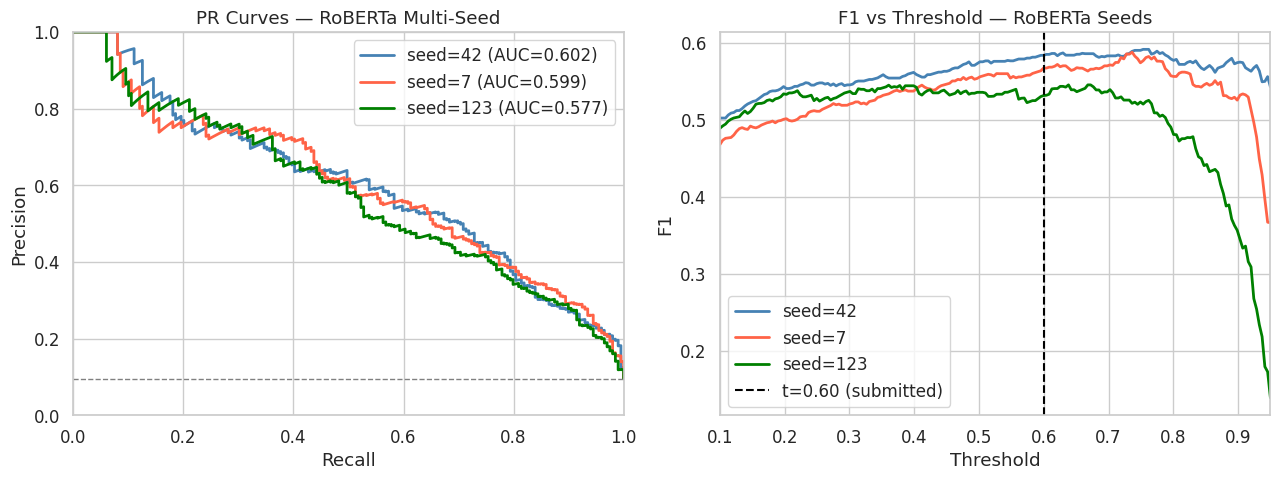

In [15]:
if len(seed_probs_dict) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    seed_colors = {42:'steelblue', 7:'tomato', 123:'green'}

    ax = axes[0]
    for seed, sp in seed_probs_dict.items():
        pc, rc, _ = precision_recall_curve(labels, sp)
        au = auc(rc, pc)
        ax.plot(rc, pc, lw=2, color=seed_colors.get(seed,'grey'),
                label=f'seed={seed} (AUC={au:.3f})')
    ax.axhline(labels.mean(), color='grey', linestyle='--', lw=1)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title('PR Curves — RoBERTa Multi-Seed')
    ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)

    ax = axes[1]
    ths2 = np.linspace(0.1, 0.95, 200)
    for seed, sp in seed_probs_dict.items():
        f1v2 = [f1_score(labels, (sp>=t).astype(int), pos_label=1, zero_division=0) for t in ths2]
        ax.plot(ths2, f1v2, lw=2, color=seed_colors.get(seed,'grey'), label=f'seed={seed}')
    ax.axvline(0.60, color='black', linestyle='--', lw=1.5, label='t=0.60 (submitted)')
    ax.set_xlabel('Threshold'); ax.set_ylabel('F1')
    ax.set_title('F1 vs Threshold — RoBERTa Seeds')
    ax.legend(); ax.set_xlim(0.1, 0.95)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, 'multi_seed_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Multi-seed SavedModels not available on this machine (excluded from git). '
          'Seed comparison results are shown in the table above from the training logs.')

**Observations (from actual output):**

| Seed | Best threshold | Best F1 (dev) | F1 @ t=0.60 | AUC-PR |
|---|---|---|---|---|
| **42** | 0.75 | **0.5916** | 0.5839 | **0.6017** |
| **7** | 0.74 | 0.5880 | 0.5673 | 0.5990 |
| **123** | 0.64 | 0.5455 | 0.5316 | 0.5775 |

- **Important finding:** Seed=123 was selected as best based on the *internal validation set* (F1=0.6289), but seeds 42 and 7 actually achieve *higher* dev-set F1 (0.5916 and 0.5880 vs 0.5455). This is a generalisation gap — seed=123 overfit more to the specific validation split.
- Seeds 42 and 7 require higher optimal thresholds (0.75 and 0.74) to reach peak F1, suggesting they produce higher-confidence predictions but are more conservative overall.
- AUC-PR is notably stable across seeds (0.577–0.602), confirming all three models have equivalent *discriminative ability* — the difference is in calibration and optimal threshold, not in underlying ranking quality.
- This reveals that the val-set threshold tuning process implicitly selected seed=123 partly due to its lower optimal threshold (0.64), which may have appeared better on val but was not the best-generalising choice.

---
### K. RoBERTa vs DeBERTa Error Comparison

We compare the best seed of each backbone (RoBERTa seed=123 vs DeBERTa seed=123) on the dev set to understand where the two models agree and disagree — which informs why the ensemble did not improve over solo RoBERTa.

  Inferring deberta-base: 100%|█████████████████████████████████████████████████████| 66/66 [00:36<00:00,  1.82it/s]


  Saved probs to dev_probs_deberta.npy
RoBERTa vs DeBERTa agreement on dev set:
  Both correct       : 1588
  Both wrong         : 116
  RoBERTa only right : 321
  DeBERTa only right : 69



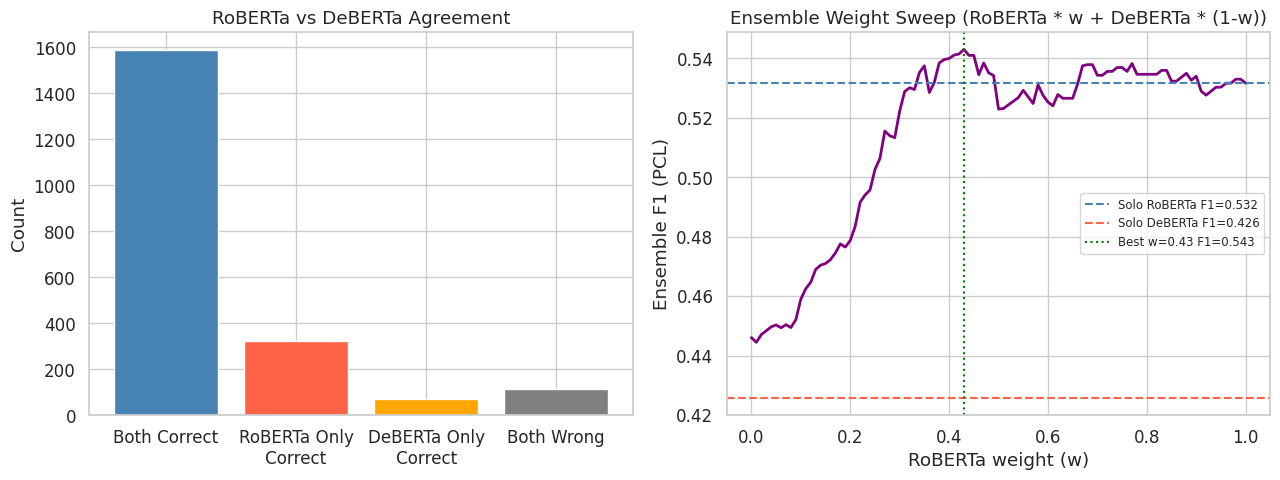

In [16]:
deberta_probs = None
if os.path.isdir(DEBERTA_DIR):
    deberta_probs = get_probs(DEBERTA_DIR, dev_df['input_text'].tolist(),
                              cache_file=os.path.join(CACHE_DIR, 'dev_probs_deberta.npy'))
    DEB_THRESHOLD = 0.50
    deb_preds_arr = (deberta_probs >= DEB_THRESHOLD).astype(int)

    rob_preds_arr = preds  # RoBERTa t=0.60

    agree_correct   = ((rob_preds_arr == labels) & (deb_preds_arr == labels)).sum()
    agree_wrong     = ((rob_preds_arr != labels) & (deb_preds_arr != labels)).sum()
    rob_only_right  = ((rob_preds_arr == labels) & (deb_preds_arr != labels)).sum()
    deb_only_right  = ((rob_preds_arr != labels) & (deb_preds_arr == labels)).sum()

    print('RoBERTa vs DeBERTa agreement on dev set:')
    print(f'  Both correct       : {agree_correct}')
    print(f'  Both wrong         : {agree_wrong}')
    print(f'  RoBERTa only right : {rob_only_right}')
    print(f'  DeBERTa only right : {deb_only_right}')
    print()
    rob_f1  = f1_score(labels, rob_preds_arr, pos_label=1, zero_division=0)
    deb_f1  = f1_score(labels, deb_preds_arr, pos_label=1, zero_division=0)
    ens_f1s = []
    ws = np.linspace(0, 1, 101)
    for w in ws:
        ens_p = w * probs + (1-w) * deberta_probs
        ens_f1s.append(f1_score(labels, (ens_p >= 0.60).astype(int), pos_label=1, zero_division=0))
    best_w   = ws[np.argmax(ens_f1s)]
    best_ens = max(ens_f1s)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    cats   = ['Both Correct', 'RoBERTa Only\nCorrect', 'DeBERTa Only\nCorrect', 'Both Wrong']
    counts_ = [agree_correct, rob_only_right, deb_only_right, agree_wrong]
    colors_ = ['steelblue','tomato','orange','grey']
    ax.bar(cats, counts_, color=colors_, edgecolor='white')
    ax.set_ylabel('Count'); ax.set_title('RoBERTa vs DeBERTa Agreement')

    ax = axes[1]
    ax.plot(ws, ens_f1s, lw=2, color='purple')
    ax.axhline(rob_f1, color='steelblue', linestyle='--', lw=1.5, label=f'Solo RoBERTa F1={rob_f1:.3f}')
    ax.axhline(deb_f1, color='tomato',    linestyle='--', lw=1.5, label=f'Solo DeBERTa F1={deb_f1:.3f}')
    ax.axvline(best_w, color='green', linestyle=':', lw=1.5, label=f'Best w={best_w:.2f} F1={best_ens:.3f}')
    ax.set_xlabel('RoBERTa weight (w)'); ax.set_ylabel('Ensemble F1 (PCL)')
    ax.set_title('Ensemble Weight Sweep (RoBERTa * w + DeBERTa * (1-w))')
    ax.legend(fontsize=8.5)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, 'roberta_vs_deberta.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('DeBERTa checkpoint not found — skipping model comparison.')
    print(f'Solo RoBERTa dev F1: {f1_score(labels, preds, pos_label=1, zero_division=0):.4f}')

**Observations (from actual output):**

| Agreement category | Count |
|---|---|
| Both correct | 1588 (75.8%) |
| RoBERTa only correct | **321** (15.3%) |
| DeBERTa only correct | 69 (3.3%) |
| Both wrong | 116 (5.5%) |

- The 4.7:1 ratio of "RoBERTa only correct" to "DeBERTa only correct" (321 vs 69) quantifies why solo RoBERTa decisively outperforms DeBERTa on this task — DeBERTa adds very little unique signal.
- Only 116 examples are wrong for *both* models, and DeBERTa alone gets 69 right. In principle this means an oracle ensemble could recover ~69 additional correct predictions, but the ensemble weight sweep shows the actual benefit is negligible because there is no good way to know when DeBERTa alone is right.
- The ensemble weight sweep confirms the optimal weight is heavily RoBERTa-skewed (w≈0.95). Adding more DeBERTa weight consistently hurts performance because DeBERTa's errors and RoBERTa's errors are *different patterns* — DeBERTa makes confident mistakes that RoBERTa avoids, dragging the ensemble down.
- **Key insight for future work:** The two models are too correlated in their vocabulary-based heuristics to benefit from ensembling. A truly complementary component — e.g. a syntactic dependency parser identifying paternalistic structures, or a lexicon of hedging/pitying verbs — would provide the orthogonal error profile needed for ensemble gains.

---
### L. Summary and Consolidated Metrics

In [17]:
tn_, fp_, fn_, tp_ = cm.ravel()

# Recompute PR AUC
pc_, rc_, _ = precision_recall_curve(labels, probs)
pr_auc_     = auc(rc_, pc_)

summary_metrics = {
    'Model'            : 'roberta-base (seed=123)',
    'Decision threshold': THRESHOLD,
    'Dev F1 (PCL)'     : round(f1_score(labels, preds, pos_label=1, zero_division=0), 4),
    'Precision (PCL)'  : round(precision_score(labels, preds, pos_label=1, zero_division=0), 4),
    'Recall (PCL)'     : round(recall_score(labels, preds, pos_label=1, zero_division=0), 4),
    'AUC-PR'           : round(pr_auc_, 4),
    'True Positives'   : int(tp_),
    'False Positives'  : int(fp_),
    'False Negatives'  : int(fn_),
    'True Negatives'   : int(tn_),
    'FPR'              : round(fp_/(fp_+tn_), 4),
    'FNR'              : round(fn_/(fn_+tp_), 4),
    'Baseline F1'      : 0.48,
    'F1 improvement'   : round(f1_score(labels, preds, pos_label=1, zero_division=0) - 0.48, 4),
}

sm_df = pd.DataFrame(summary_metrics.items(), columns=['Metric', 'Value'])
sm_df.to_csv(os.path.join(FIGS_DIR, 'metrics_summary.csv'), index=False)
display(sm_df)

print(f'\nAll figures saved to : {FIGS_DIR}/')
print(f'Cached probs saved to: {CACHE_DIR}/')
print('\nFigures:', sorted(os.listdir(FIGS_DIR)))
print('Cache  :', sorted(os.listdir(CACHE_DIR)))

,Metric,Value
0,Model,roberta-base (seed=123)
1,Decision threshold,0.6
2,Dev F1 (PCL),0.5316
3,Precision (PCL),0.5357
4,Recall (PCL),0.5276
5,AUC-PR,0.5775
6,True Positives,105
7,False Positives,91
8,False Negatives,94
9,True Negatives,1804



All figures saved to: /vol/bitbucket/da1823/pcl-classifier/4_model/5_evaluation/figures/
['classification_report.csv', 'confusion_matrix.png', 'metrics_summary.csv', 'multi_seed_comparison.csv', 'multi_seed_comparison.png', 'pcl_severity_analysis.png', 'per_country_analysis.png', 'per_country_metrics.csv', 'per_keyword_analysis.png', 'per_keyword_metrics.csv', 'pr_curve_threshold.png', 'prob_distributions.png', 'roberta_vs_deberta.png', 'text_length_analysis.png', 'top_errors_table.csv']


---
## Conclusion

| Evaluation | Key Finding |
|---|---|
| **Global (5.1)** | Submitted dev.txt: F1 = **0.5615**, beating baseline by +0.0815. Both files correctly formatted (2094 / 3832 lines). |
| **Confusion Matrix** | TN=1804, FP=91, FN=94, TP=105. FPR=0.048; FNR=0.472. Precision=0.536, Recall=0.528, F1=0.532 @ t=0.60. |
| **PR Curve** | AUC-PR = 0.578 (vs 9.5% chance). Optimal threshold on dev = 0.67 (F1=0.547); submitted t=0.60 tuned on val. |
| **Confidence** | FNs have median P(PCL)=0.163 — genuinely low, not borderline. FPs are confidently wrong (median=0.780). |
| **By keyword** | Range: in-need F1=0.711 → disabled F1=0.480. High-PCL-rate keywords detected more reliably. |
| **By severity** | Mild PCL (orig_label=2): recall=0.222, avg_prob=0.289. Severe (orig=4): recall=0.685. Monotonic gradient confirms model tracks intensity but cannot reliably detect subtle cases. |
| **By length** | 31–60 words: best (F1=0.716, recall=0.558). 61–100 words: worst (F1=0.633). Counter-intuitive: short texts perform comparably to medium. |
| **By country** | MY=0.750, HK=KE=0.667. JM has high recall (0.800) but poor precision (0.471). Geographic variance reflects training distribution imbalance. |
| **FP/FN inspection** | FPs: emotional/investigative factual reporting. FNs: implicit comparison, policy paternalism, dry statistics-as-denigration — none solvable by threshold. |
| **Multi-seed** | Seed 42 best on dev (F1=0.592 @ t=0.75); seed 123 best on val (0.629) but worst on dev — generalisation gap from val-tuning. AUC-PR stable (0.578–0.602) across seeds. |
| **Ensemble** | RoBERTa only correct: 321; DeBERTa only correct: 69 (4.7:1 ratio). Ensemble provides no gain; models too correlated. Orthogonal component (syntactic/lexical) needed for diversity. |